## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')

In [4]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [5]:
# TODO: drop the Customer ID column  
df.drop(columns=['Customer ID'])

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [ ]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

In [49]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

In [ ]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

In [ ]:
# TODO: univariate — describe numeric columns
df.describe()

In [6]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']


## **EDA**

### **Item Purchased**

In [12]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_top   = male_df['Item Purchased'].value_counts().reset_index(name=['Item Purchased', 'Count'])
female_top = female_df['Item Purchased'].value_counts().reset_index(name=['Item Purchased', 'Count'])
all_top    = df['Item Purchased'].value_counts().reset_index(name=['Item Purchased', 'Count'])



C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_19944\4275547031.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


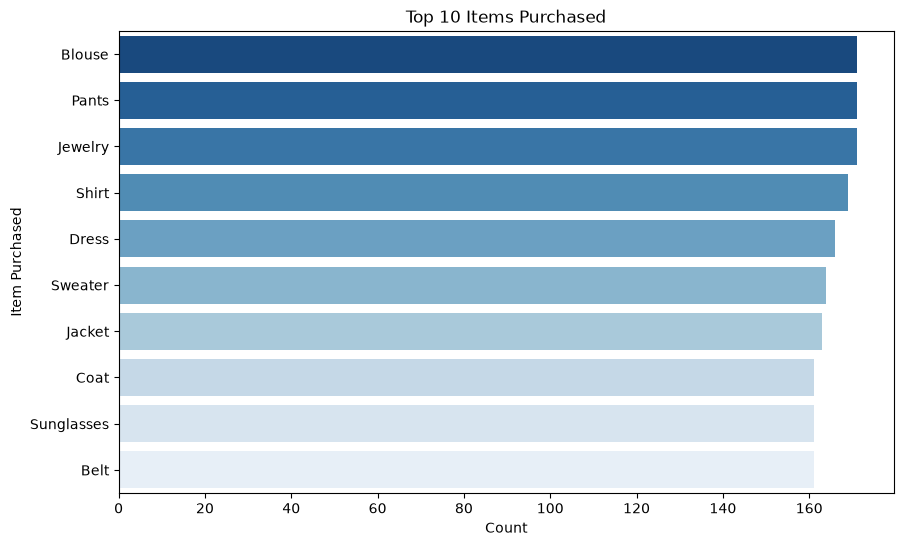

In [15]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
all_top = df['Item Purchased'].value_counts().rename_axis('Item Purchased').reset_index(name='Count')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=all_top.head(10),
    x='Count',
    y='Item Purchased',
    palette='Blues_r'
)
plt.title('Top 10 Items Purchased')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()


C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_19944\1941630513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


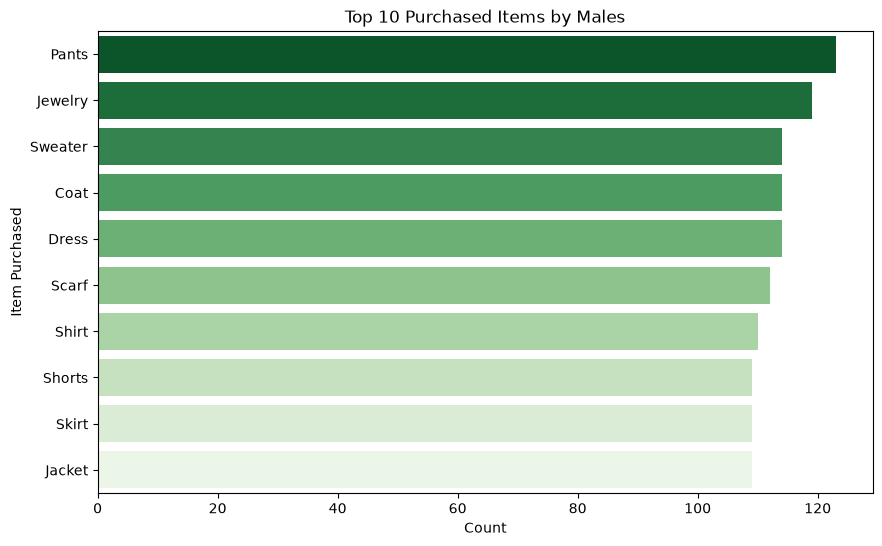

In [17]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
male_top = male_df['Item Purchased'].value_counts() \
    .rename_axis('Item Purchased') \
    .reset_index(name='Count')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=male_top.head(10),
    x='Count',
    y='Item Purchased',
    palette='Greens_r'
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()


C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_19944\3606633607.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


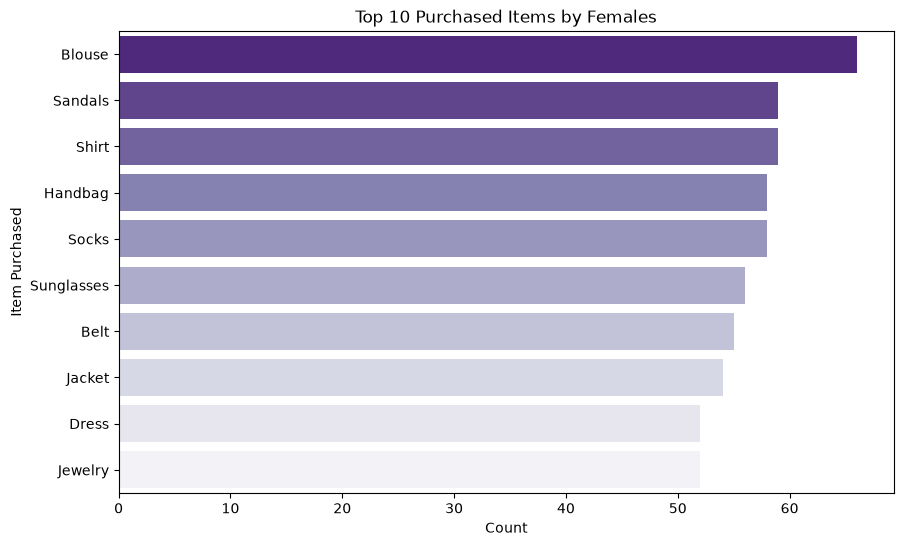

In [18]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
female_top = female_df['Item Purchased'].value_counts() \
    .rename_axis('Item Purchased') \
    .reset_index(name='Count')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=female_top.head(10),
    x='Count',
    y='Item Purchased',
    palette='Purples_r'
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()


In [19]:
# TODO: count Size with value_counts() for all customers
size_counts = df['Size'].value_counts().rename_axis('Size').reset_index(name='Count')
print(size_counts)


  Size  Count
0    M   1755
1    L   1053
2    S    663
3   XL    429


In [23]:
# TODO: count Size with value_counts() for male_df and female_df
male_size_counts   = male_df['Size'].value_counts()
female_size_counts = female_df['Size'].value_counts()

print (male_size_counts)
print(female_size_counts)


Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [26]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts()
print(ctg)

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


In [27]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
male_ctg   = male_df['Category'].value_counts()
female_ctg = female_df['Category'].value_counts()

print(male_ctg)
print(female_ctg)

Category
Clothing       1181
Accessories     848
Footwear        400
Outerwear       223
Name: count, dtype: int64
Category
Clothing       556
Accessories    392
Footwear       199
Outerwear      101
Name: count, dtype: int64


C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_19944\219686833.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


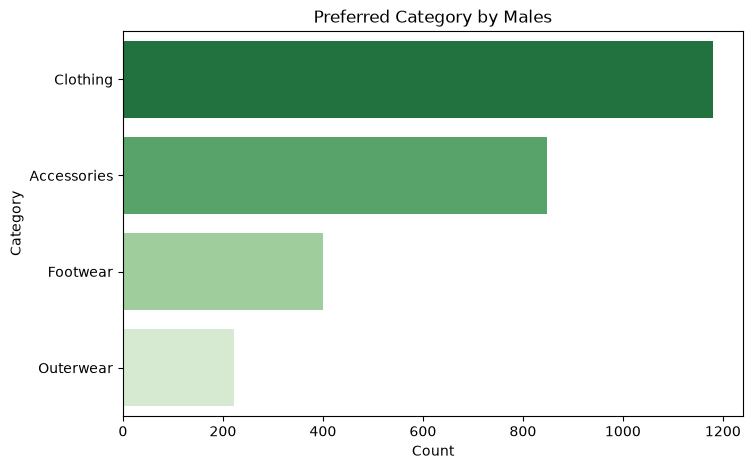

In [28]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    x=male_ctg.values,
    y=male_ctg.index,
    palette='Greens_r'
)
plt.title("Preferred Category by Males")
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_19944\737340962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


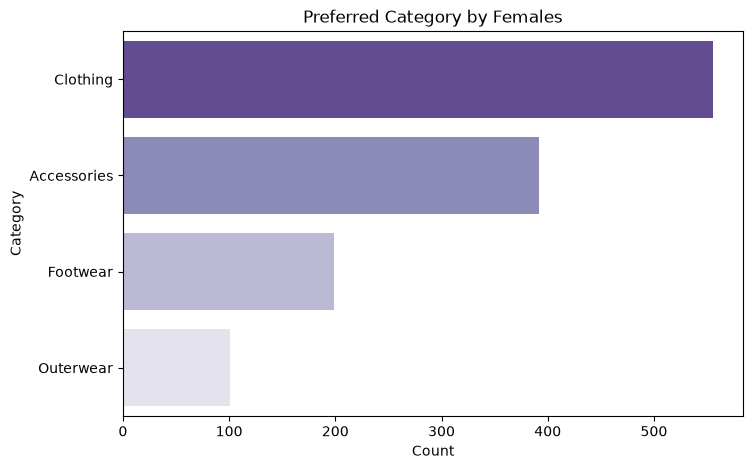

In [29]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    x=female_ctg.values,
    y=female_ctg.index,
    palette='Purples_r'
)
plt.title("Preferred Category by Females")
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()


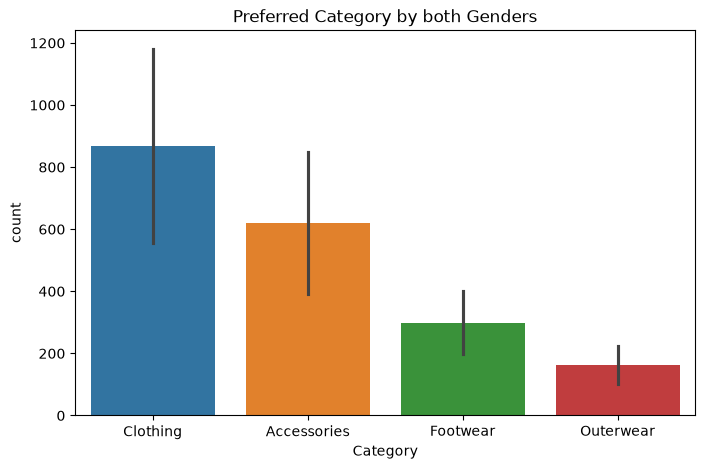

In [31]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
male_ctg   = male_df['Category'].value_counts().reset_index()
male_ctg.columns = ['Category','count']
male_ctg['Gender'] = 'Male'

female_ctg = female_df['Category'].value_counts().reset_index()
female_ctg.columns = ['Category','count']
female_ctg['Gender'] = 'Female'

ctg = pd.concat([male_ctg, female_ctg])

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()

In [35]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())


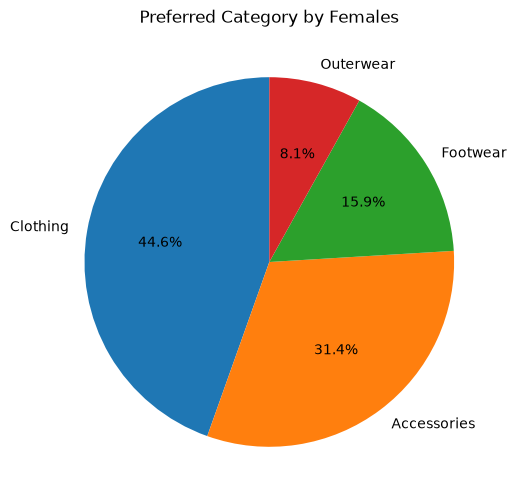

In [34]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    female_df['Category'].value_counts(),
    labels=female_df['Category'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Preferred Category by Females")
plt.show()


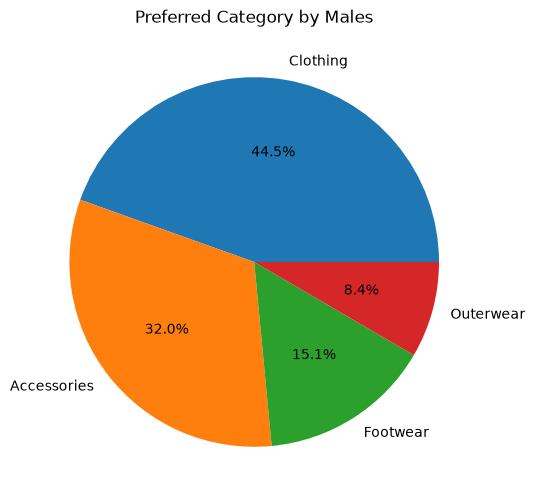

In [36]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [42]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()



In [40]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()

In [43]:
print(avg_cr_m,avg_cr_f)

3.7319220999153258 3.7044964028776977


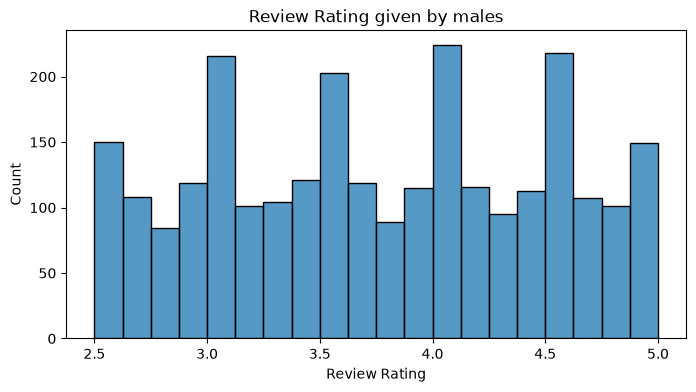

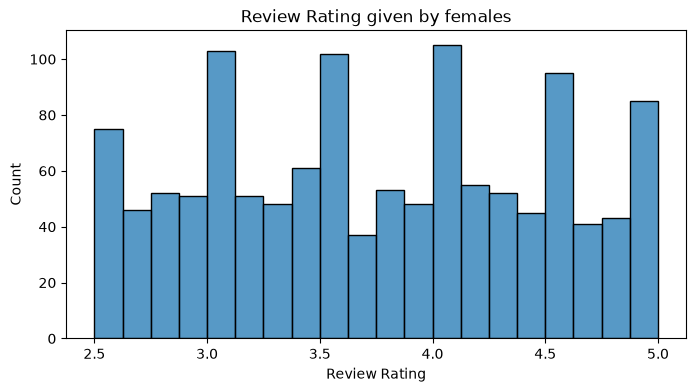

In [46]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()


In [47]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
rating_counts_m = cr_m['Review Rating'].value_counts()

### **Purchase Amount (USD)**

In [51]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()
print(m_tpa,"|",f_tpa)

157890 | 75191


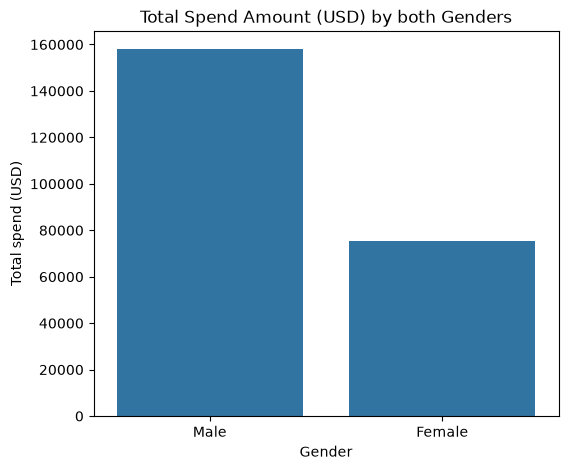

In [52]:
# TODO: plot total spend by gender with sns.barplot()
total_spend = pd.DataFrame({
    'Gender': ['Male', 'Female'],'TotalSpend': [m_tpa, f_tpa]})
plt.figure(figsize=(6, 5))
sns.barplot(
    data=total_spend,
    x='Gender',
    y='TotalSpend'
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [53]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [54]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [55]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

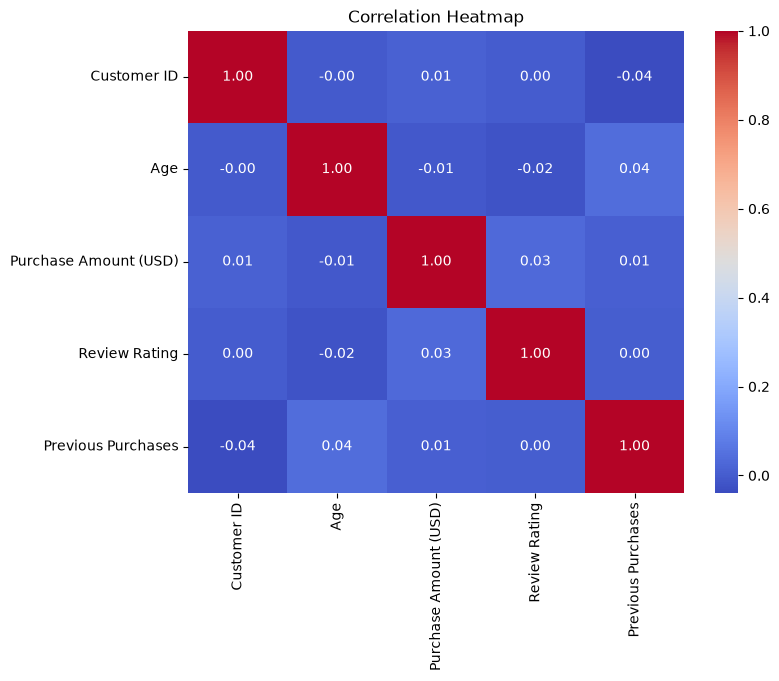

In [56]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,        # hiển thị giá trị correlation trên ô
    cmap='coolwarm',   # màu sắc trực quan
    fmt=".2f"          # định dạng số thập phân
)
plt.title("Correlation Heatmap")
plt.show()


### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [57]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()


,Customer ID,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,1,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,...,0,1,1,0,0,0,0,1,0,0
1,2,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,...,0,1,1,0,0,0,0,1,0,0
2,3,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,...,0,1,0,0,1,0,0,1,0,0
3,4,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,...,0,1,0,1,0,0,0,0,1,0
4,5,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,...,0,1,0,1,0,0,0,1,0,0


In [58]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()


,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [59]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'],bins=[0, 100, 500, float('inf')],labels=['Low', 'Medium', 'High'])

df['Amount_bin'].value_counts()


Amount_bin
Low       3900
Medium       0
High         0
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.